# Bayesian vs. Frequentist A/B Analysis

**Dataset:** Hillstrom MineThatData — the **Womens E-Mail vs. No E-Mail** arms,
`visit` outcome. The same comparison Week 1 analysed with a two-proportion
z-test and Week 5 used for the bandit's power trade-off, re-analysed here two
ways.

**Goal of this notebook:**

1. Run the standard **frequentist** read of this test — a two-proportion
   z-test p-value and a Wald confidence interval on the difference in visit
   rates (the Week 1 machinery).
2. Implement the **Bayesian** counterpart from scratch with a Beta-Bernoulli
   conjugate model: a posterior on each rate, a credible interval on the
   lift, `P(treatment > control)`, and the decision-theoretic **expected
   loss** of each ship decision.
3. Show **where the two frameworks agree and where they diverge** — they
   give nearly identical intervals at Hillstrom's full sample size, so the
   interesting differences show up (a) in what each number is *allowed to
   claim*, (b) at small samples, (c) under an informative prior, and (d)
   under optional stopping / peeking (a direct callback to Week 1).

Companion writeup: `writeups/bayesian_vs_frequentist.md`. Implementation:
`src/bayesian_ab.py`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import sys
sys.path.append("../src")
from bayesian_ab import (
    BetaPosterior, update_beta, prob_treatment_beats_control, posterior_lift,
    expected_loss, frequentist_two_proportion, simulate_bayesian_optional_stopping,
)
from power_analysis import minimum_detectable_effect

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = "../writeups/figures"
RNG = np.random.default_rng(7)


## 1. Setup: one comparison, two frameworks

Week 1 established the frequentist result for the Mens campaign; the Womens
arm is the one Week 5's bandit struggled to call. Its raw numbers:


In [2]:
df = pd.read_csv("../data/raw/hillstrom.csv")

control = df.loc[df["segment"] == "No E-Mail", "visit"].values
treatment = df.loc[df["segment"] == "Womens E-Mail", "visit"].values

n_c, conv_c = len(control), int(control.sum())
n_t, conv_t = len(treatment), int(treatment.sum())

summary = pd.DataFrame({
    "arm": ["No E-Mail (control)", "Womens E-Mail (treatment)"],
    "n": [n_c, n_t],
    "visits": [conv_c, conv_t],
    "visit_rate": [conv_c / n_c, conv_t / n_t],
})
summary


,arm,n,visits,visit_rate
0,No E-Mail (control),21306,2262,0.106167
1,Womens E-Mail (treatment),21387,3238,0.151400


## 2. The frequentist read

The Week 1 approach: a two-sided two-proportion z-test (pooled variance) for
the p-value, and an unpooled Wald standard error for the 95% confidence
interval on the difference in rates.

The p-value answers exactly one question: *if there were truly no difference
between the arms, how often would random assignment alone produce a gap at
least this large?* The confidence interval is the set of null differences
that this data would not reject — and its 95% coverage is a property of the
**procedure** over hypothetical repeat experiments, not a probability
statement about this one interval.


In [3]:
freq = frequentist_two_proportion(n_c, conv_c, n_t, conv_t)
freq_tbl = pd.DataFrame({
    "quantity": ["control rate", "treatment rate", "difference (t - c)",
                 "z statistic", "p-value (two-sided)",
                 "95% CI low", "95% CI high"],
    "value": [freq["p_control"], freq["p_treatment"], freq["diff"],
              freq["z"], freq["p_value"], freq["ci_low"], freq["ci_high"]],
})
freq_tbl


,quantity,value
0,control rate,0.106167
1,treatment rate,0.151400
2,difference (t - c),0.045233
3,z statistic,13.949181
4,p-value (two-sided),0.000000
5,95% CI low,0.038894
6,95% CI high,0.051572


The difference is **+4.52 percentage points** (visit rate 10.6% → 15.1%),
`z ≈ 13.9`, `p` far below any threshold, 95% CI **[+3.89pp, +5.16pp]**. An
unambiguous, well-powered positive result — as expected from a ~21,300-per-arm
test looking for an effect this size.


## 3. The Bayesian read: Beta-Bernoulli from scratch

`visit` is binary, so each arm's rate `θ` has a **conjugate** Bayesian
analysis. Put a `Beta(a, b)` prior on `θ`; observe `s` visits in `n`
customers; the posterior is exactly

$$\theta \mid \text{data} \;\sim\; \text{Beta}(a + s,\; b + n - s)$$

No MCMC — the posterior is a closed-form distribution. Start from a **flat
`Beta(1, 1)`** prior on each arm (uniform on [0, 1] — every rate equally
plausible a priori), which makes the Bayesian and frequentist point
estimates line up almost exactly and isolates the *interpretation*
difference. Prior choice gets its own stress test in Section 6.


In [4]:
PRIOR_A, PRIOR_B = 1.0, 1.0

post_c = update_beta(PRIOR_A, PRIOR_B, n_c, conv_c)
post_t = update_beta(PRIOR_A, PRIOR_B, n_t, conv_t)

for name, post in [("control", post_c), ("treatment", post_t)]:
    lo, hi = post.credible_interval(0.95)
    print(f"{name:10s}  Beta({post.alpha:.0f}, {post.beta:.0f})  "
          f"posterior mean = {post.mean:.4f}  95% credible interval = [{lo:.4f}, {hi:.4f}]")


control     Beta(2263, 19045)  posterior mean = 0.1062  95% credible interval = [0.1021, 0.1104]
treatment   Beta(3239, 18150)  posterior mean = 0.1514  95% credible interval = [0.1467, 0.1563]


In [5]:
# Posterior of the treatment effect (treatment - control), by Monte Carlo
# from the two posteriors. P(T>C) and this interval have exact closed forms
# for Beta-Bernoulli; sampling is used so the same code works for any metric,
# and the Monte Carlo error is reported below.
lift = posterior_lift(post_c, post_t, level=0.95, random_state=0)
pbt = prob_treatment_beats_control(post_c, post_t, random_state=0)
loss = expected_loss(post_c, post_t, random_state=0)

print(f"posterior mean absolute lift : {lift['abs_mean']:+.4f}  "
      f"95% credible interval [{lift['abs_ci'][0]:+.4f}, {lift['abs_ci'][1]:+.4f}]")
print(f"posterior mean relative lift : {lift['rel_mean']:+.1%}  "
      f"95% credible interval [{lift['rel_ci'][0]:+.1%}, {lift['rel_ci'][1]:+.1%}]")
print(f"P(treatment > control)       : {pbt['prob']:.4f}  (Monte Carlo SE {pbt['mc_se']:.5f})")
print(f"expected loss, ship treatment: {loss['loss_ship_treatment']:.6f}")
print(f"expected loss, ship control  : {loss['loss_ship_control']:.6f}")


posterior mean absolute lift : +0.0452  95% credible interval [+0.0389, +0.0516]
posterior mean relative lift : +42.6%  95% credible interval [+35.6%, +50.0%]
P(treatment > control)       : 1.0000  (Monte Carlo SE 0.00000)
expected loss, ship treatment: 0.000000
expected loss, ship control  : 0.045215


`P(treatment > control) ≈ 1.00`, the posterior mean lift is **+4.52pp** with
a 95% credible interval of **[+3.89pp, +5.16pp]**, and the expected loss of
shipping the treatment (the posterior-average visit rate you would forgo if
it turned out to be the worse arm) rounds to **zero**. Every number points
the same way as the frequentist read.


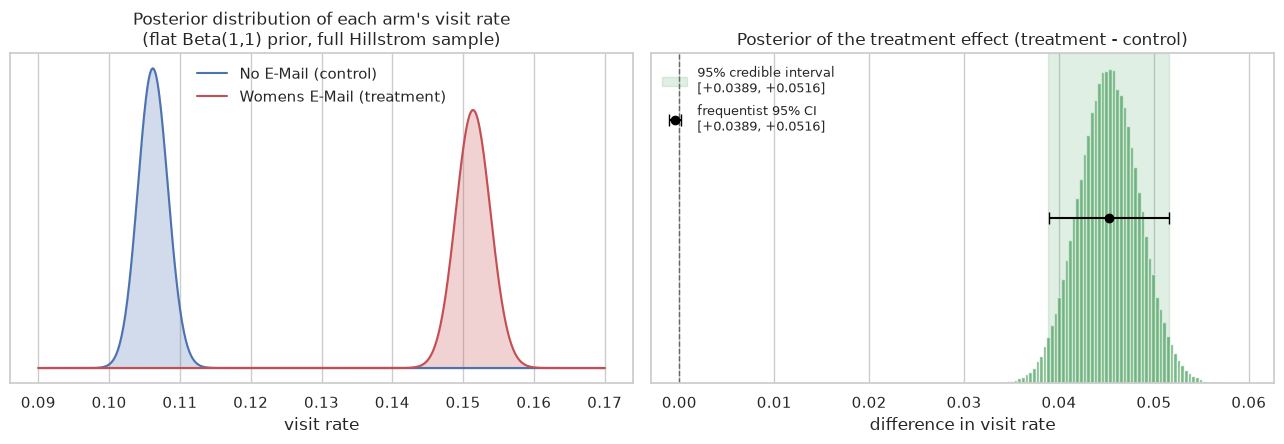

In [6]:
# --- Figure: the posteriors ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

grid = np.linspace(0.09, 0.17, 600)
for post, label, colour in [(post_c, "No E-Mail (control)", "#4C72B0"),
                            (post_t, "Womens E-Mail (treatment)", "#C44E52")]:
    dens = stats.beta.pdf(grid, post.alpha, post.beta)
    axes[0].plot(grid, dens, color=colour, label=label)
    axes[0].fill_between(grid, dens, alpha=0.25, color=colour)
axes[0].set_title("Posterior distribution of each arm's visit rate\n(flat Beta(1,1) prior, full Hillstrom sample)")
axes[0].set_xlabel("visit rate")
axes[0].set_yticks([])
axes[0].legend(frameon=False)

samples = lift["samples_abs"]
axes[1].hist(samples, bins=80, color="#55A868", alpha=0.8, density=True)
lo, hi = lift["abs_ci"]
axes[1].axvspan(lo, hi, color="#55A868", alpha=0.18,
                label=f"95% credible interval\n[{lo:+.4f}, {hi:+.4f}]")
axes[1].axvline(0, color="0.4", lw=1, ls="--")
axes[1].errorbar(freq["diff"], axes[1].get_ylim()[1] * 0.5,
                 xerr=[[freq["diff"] - freq["ci_low"]], [freq["ci_high"] - freq["diff"]]],
                 fmt="o", color="black", capsize=4,
                 label=f"frequentist 95% CI\n[{freq['ci_low']:+.4f}, {freq['ci_high']:+.4f}]")
axes[1].set_title("Posterior of the treatment effect (treatment - control)")
axes[1].set_xlabel("difference in visit rate")
axes[1].set_yticks([])
axes[1].legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/24_bayes_posteriors.png", dpi=140, bbox_inches="tight")
plt.show()


## 4. Side by side: the numbers nearly coincide, the claims don't

| | Frequentist | Bayesian (flat prior) |
|---|---|---|
| Point estimate | +4.52pp | +4.52pp (posterior mean) |
| 95% interval | [+3.89pp, +5.16pp] (confidence) | [+3.89pp, +5.16pp] (credible) |
| "Significance" number | p ≈ 0 | P(T > C) ≈ 1.00 |
| What the interval means | 95% of intervals built this way cover the true difference | 95% posterior probability the true difference is in *this* interval |
| What the significance number means | P(data this extreme \| no true effect) | P(treatment genuinely better \| this data) |
| Natural decision rule | reject H₀ if p < α | ship the arm whose expected loss < threshold of caring |

With ~21,000 observations per arm and a flat prior, the Bayesian posterior
is driven almost entirely by the likelihood, so it lands in the same place
as the frequentist sampling distribution. **The intervals match to four
decimal places.** What differs is what you are entitled to say:

- The frequentist 95% CI **[+3.89pp, +5.16pp]** either contains the true
  difference or it doesn't; the 95% describes the long-run hit rate of the
  method.
- The Bayesian 95% credible interval — the *same* numbers here — supports
  the sentence people usually *want*: "there's a 95% probability the true
  lift is between 3.89 and 5.16 points."
- `p ≈ 0` is *not* "P(no effect) ≈ 0"; `P(T > C) ≈ 1.00` genuinely is "the
  posterior probability the treatment is better."

At this sample size the choice of framework is about how you're allowed to
communicate the result, not about the result.


## 5. Where the gap shows: small samples

Shrink each arm to **n = 150** (one fixed random subsample, drawn once and
used for everything below) and re-run both analyses. This is the regime a
real early-readout or a low-traffic surface lives in.


In [7]:
N_SMALL = 150
idx_c = RNG.choice(n_c, N_SMALL, replace=False)
idx_t = RNG.choice(n_t, N_SMALL, replace=False)
c_small, t_small = control[idx_c], treatment[idx_t]
sc, st = int(c_small.sum()), int(t_small.sum())
print(f"subsample: control {sc}/{N_SMALL} = {sc/N_SMALL:.3f},  "
      f"treatment {st}/{N_SMALL} = {st/N_SMALL:.3f}")
print(f"Week 1 calculator: smallest effect n={N_SMALL}/arm can reliably detect "
      f"= {minimum_detectable_effect(0.106, N_SMALL):.3f} "
      f"(far bigger than the true ~0.045 effect — this test is underpowered by design)")


subsample: control 17/150 = 0.113,  treatment 23/150 = 0.153
Week 1 calculator: smallest effect n=150/arm can reliably detect = 0.100 (far bigger than the true ~0.045 effect — this test is underpowered by design)


In [8]:
freq_s = frequentist_two_proportion(N_SMALL, sc, N_SMALL, st)
post_c_s = update_beta(1.0, 1.0, N_SMALL, sc)
post_t_s = update_beta(1.0, 1.0, N_SMALL, st)
lift_s = posterior_lift(post_c_s, post_t_s, random_state=0)
pbt_s = prob_treatment_beats_control(post_c_s, post_t_s, random_state=0)
loss_s = expected_loss(post_c_s, post_t_s, random_state=0)

print("FREQUENTIST")
print(f"  difference {freq_s['diff']:+.4f}, p = {freq_s['p_value']:.3f}, "
      f"95% CI [{freq_s['ci_low']:+.4f}, {freq_s['ci_high']:+.4f}]  -> CI crosses 0, cannot reject H0")
print()
print("BAYESIAN (flat prior)")
print(f"  posterior mean lift {lift_s['abs_mean']:+.4f}, "
      f"95% credible interval [{lift_s['abs_ci'][0]:+.4f}, {lift_s['abs_ci'][1]:+.4f}]")
print(f"  P(treatment > control) = {pbt_s['prob']:.3f}")
print(f"  expected loss  ship treatment = {loss_s['loss_ship_treatment']:.5f}   "
      f"ship control = {loss_s['loss_ship_control']:.5f}")


FREQUENTIST
  difference +0.0400, p = 0.308, 95% CI [-0.0368, +0.1168]  -> CI crosses 0, cannot reject H0

BAYESIAN (flat prior)
  posterior mean lift +0.0395, 95% credible interval [-0.0372, +0.1176]
  P(treatment > control) = 0.843
  expected loss  ship treatment = 0.00322   ship control = 0.04274


Same 150+150 rows, two different-feeling answers:

- **Frequentist:** `p ≈ 0.31`, CI **[-3.7pp, +11.7pp]**. The honest summary
  is "inconclusive — this test cannot rule out no effect." Correct, and not
  very actionable.
- **Bayesian:** `P(T > C) ≈ 0.84`, and the decision quantities are the
  useful part. Expected loss from shipping the treatment is **~0.3pp** of
  visit rate; expected loss from keeping the control is **~4.3pp**. If the
  smallest difference the business would care about is, say, 0.5pp — the
  "threshold of caring" — then shipping the treatment is already *safe
  enough* (0.3pp < 0.5pp) while standing pat is not.

The frequentist test answers "can I reject the no-difference hypothesis at
this sample size" (no). The Bayesian decision framing answers "which arm
should I ship, and what do I expect to lose if I'm wrong" (ship treatment,
expect to lose very little) — which is the question a product decision
actually poses.

**Two honest caveats.** (1) This is one subsample; a different draw shifts
`P(T > C)` around (0.75–0.95 across seeds), which is itself the point —
small samples are unstable whichever framework you use. (2) Nothing here is
*intrinsically* Bayesian: a frequentist can also build a loss-based decision
rule. But the posterior makes "probability the treatment is better" and
"expected cost of being wrong" fall out directly, whereas the p-value has to
be argued around.


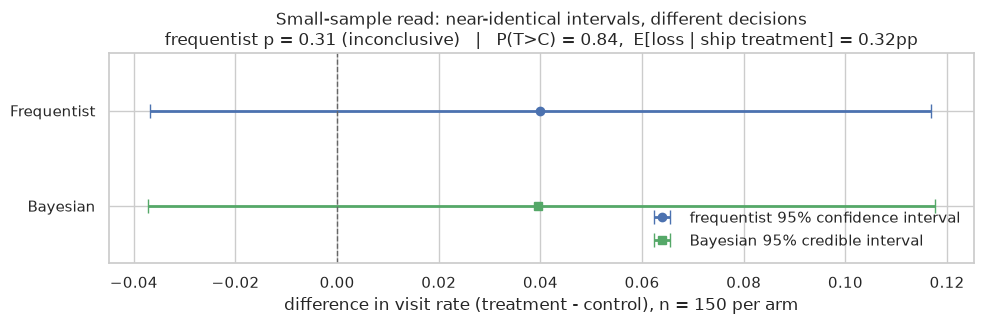

In [9]:
# --- Figure: small-sample comparison ---
fig, ax = plt.subplots(figsize=(10, 3.4))

ax.errorbar(freq_s["diff"], 1, xerr=[[freq_s["diff"] - freq_s["ci_low"]],
            [freq_s["ci_high"] - freq_s["diff"]]], fmt="o", color="#4C72B0",
            capsize=5, lw=2, label="frequentist 95% confidence interval")
ax.errorbar(lift_s["abs_mean"], 0, xerr=[[lift_s["abs_mean"] - lift_s["abs_ci"][0]],
            [lift_s["abs_ci"][1] - lift_s["abs_mean"]]], fmt="s", color="#55A868",
            capsize=5, lw=2, label="Bayesian 95% credible interval")
ax.axvline(0, color="0.4", ls="--", lw=1)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Bayesian", "Frequentist"])
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("difference in visit rate (treatment - control), n = 150 per arm")
ax.set_title("Small-sample read: near-identical intervals, different decisions\n"
             f"frequentist p = {freq_s['p_value']:.2f} (inconclusive)   |   "
             f"P(T>C) = {pbt_s['prob']:.2f},  E[loss | ship treatment] = {loss_s['loss_ship_treatment']*100:.2f}pp")
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/25_bayes_vs_freq_smalln.png", dpi=140, bbox_inches="tight")
plt.show()


## 6. Prior sensitivity: when does the prior actually matter?

The standard objection to a Bayesian analysis is "you can get any answer you
want by picking the prior." Test it: four priors, from flat to a genuinely
opinionated one, each applied to **both** the n = 150 subsample and the full
sample.

| Prior | Interpretation |
|---|---|
| `Beta(1, 1)` | flat — every rate equally plausible |
| `Beta(0.5, 0.5)` | Jeffreys — the standard "objective" reference prior |
| `Beta(2, 16)` | weakly informative — centred near 11%, worth ~18 pseudo-observations |
| `Beta(33, 267)` | tight & skeptical — centred at 11%, worth ~300 pseudo-observations (2x the subsample) |


In [10]:
priors = {
    "Beta(1,1) flat":            (1.0, 1.0),
    "Beta(0.5,0.5) Jeffreys":    (0.5, 0.5),
    "Beta(2,16) weak":           (2.0, 16.0),
    "Beta(33,267) tight":        (33.0, 267.0),
}

rows = []
for label, (a, b) in priors.items():
    for tag, nn, s_c, s_t in [("n=150", N_SMALL, sc, st),
                              ("full", n_c, conv_c, conv_t)]:
        pc = update_beta(a, b, nn, s_c)
        pt = update_beta(a, b, nn, s_t)
        lf = posterior_lift(pc, pt, random_state=0)
        pb = prob_treatment_beats_control(pc, pt, random_state=0)["prob"]
        rows.append({"prior": label, "sample": tag,
                     "post_mean_lift": lf["abs_mean"],
                     "cred_low": lf["abs_ci"][0], "cred_high": lf["abs_ci"][1],
                     "P(T>C)": pb})

prior_tbl = pd.DataFrame(rows)
prior_tbl


,prior,sample,post_mean_lift,cred_low,cred_high,P(T>C)
0,"Beta(1,1) flat",n=150,0.039519,-0.037192,0.117557,0.842895
1,"Beta(1,1) flat",full,0.045791,0.039449,0.052152,1.000000
2,"Beta(0.5,0.5) Jeffreys",n=150,0.039758,-0.036336,0.117142,0.846530
3,"Beta(0.5,0.5) Jeffreys",full,0.045793,0.039452,0.052154,1.000000
4,"Beta(2,16) weak",n=150,0.035759,-0.035967,0.107931,0.836675
5,"Beta(2,16) weak",full,0.045756,0.039418,0.052114,1.000000
6,"Beta(33,267) tight",n=150,0.013312,-0.028899,0.055753,0.732785
7,"Beta(33,267) tight",full,0.045159,0.038867,0.051469,1.000000


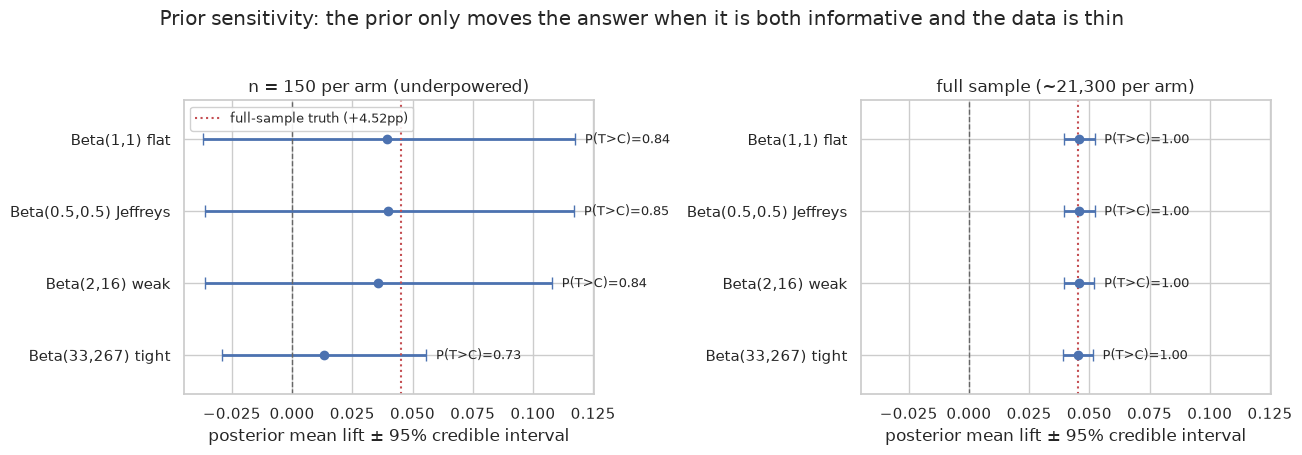

In [11]:
# --- Figure: prior sensitivity ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharex=True)
for ax, tag, title in [(axes[0], "n=150", "n = 150 per arm (underpowered)"),
                       (axes[1], "full", "full sample (~21,300 per arm)")]:
    sub = prior_tbl[prior_tbl["sample"] == tag].reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]
    ax.errorbar(sub["post_mean_lift"], ypos,
                xerr=[sub["post_mean_lift"] - sub["cred_low"],
                      sub["cred_high"] - sub["post_mean_lift"]],
                fmt="o", capsize=4, lw=2, color="#4C72B0")
    for y, (_, r) in zip(ypos, sub.iterrows()):
        ax.text(r["cred_high"] + 0.004, y, f"P(T>C)={r['P(T>C)']:.2f}",
                va="center", fontsize=9)
    ax.axvline(0, color="0.4", ls="--", lw=1)
    ax.axvline(0.0452, color="#C44E52", ls=":", lw=1.5, label="full-sample truth (+4.52pp)")
    ax.set_yticks(ypos)
    ax.set_yticklabels(sub["prior"])
    ax.set_title(title)
    ax.set_xlabel("posterior mean lift ± 95% credible interval")
    ax.margins(y=0.18)
axes[0].legend(frameon=True, loc="upper left", fontsize=9, framealpha=0.9)
fig.suptitle("Prior sensitivity: the prior only moves the answer when it is both informative and the data is thin", y=1.03)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/26_prior_sensitivity.png", dpi=140, bbox_inches="tight")
plt.show()


**Full sample:** all four priors give the same posterior to three decimal
places. ~21,000 observations swamp even a prior worth 300 pseudo-counts —
"you can get any answer with the prior" is simply false at scale.

**n = 150:** flat, Jeffreys, and the weakly-informative prior still agree
closely (posterior lift ≈ +3.6 to +4.0pp, `P(T>C)` ≈ 0.84). Only the
**tight** `Beta(33, 267)` prior — deliberately worth twice the data and
centred on "no effect" — visibly pulls the posterior toward zero (lift
≈ +1.3pp, `P(T>C)` ≈ 0.73).

That is the honest rule: a prior changes the conclusion only when it is
**both** genuinely informative **and** competing with a small dataset — and
in that case you should have to *defend* it (where do 300 pseudo-observations
of "no effect" come from?). A weak or reference prior with a normal sample
size is not a knob that lets you dial the result.


## 7. Peeking, Bayesian edition — a direct callback to Week 1

Week 1 showed that checking a frequentist test at 20 interim looks and
stopping at the first `p < 0.05` inflates the false-positive rate from 5% to
~24%. Does switching to a Bayesian posterior probability fix that?

Same simulation design: **no true effect**, 2,000 simulated experiments,
accumulate data in both arms, recompute `P(T > C)` at 20 evenly spaced looks,
and stop the first time `P(T > C) > 0.95` (ship treatment) or `< 0.05` (ship
control). Compare that peek-and-stop rule against a single look at the end.


In [12]:
null_sim = simulate_bayesian_optional_stopping(
    baseline_rate=0.1062, n_per_arm_max=4000, n_checks=20,
    true_effect=0.0, prob_threshold=0.95, n_simulations=2000, random_state=1,
)
power_sim = simulate_bayesian_optional_stopping(
    baseline_rate=0.1062, n_per_arm_max=4000, n_checks=20,
    true_effect=0.045, prob_threshold=0.95, n_simulations=2000, random_state=1,
)
print("NULL (no true effect):")
print(f"  fixed-horizon  P(ship treatment) = {null_sim['fixed_horizon_ship_rate']:.3f}")
print(f"  peek & stop    P(ship treatment) = {null_sim['peeking_ship_rate']:.3f}")
print(f"  peek & stop    P(stop for either arm) = {null_sim['peeking_any_stop_rate']:.3f}")
print()
print("TRUE EFFECT +0.045:")
print(f"  fixed-horizon  P(ship treatment) = {power_sim['fixed_horizon_ship_rate']:.3f}")
print(f"  peek & stop    P(ship treatment) = {power_sim['peeking_ship_rate']:.3f}")


NULL (no true effect):
  fixed-horizon  P(ship treatment) = 0.048
  peek & stop    P(ship treatment) = 0.210
  peek & stop    P(stop for either arm) = 0.433

TRUE EFFECT +0.045:
  fixed-horizon  P(ship treatment) = 1.000
  peek & stop    P(ship treatment) = 0.999


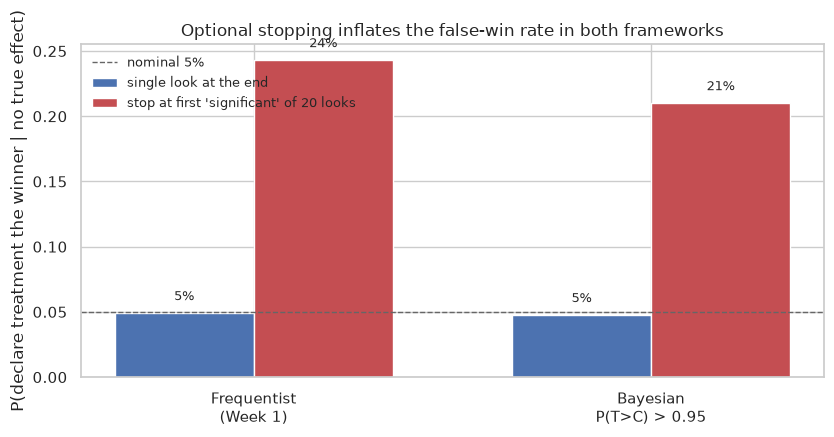

In [13]:
# --- Figure: Bayesian peeking vs the Week 1 frequentist result ---
fig, ax = plt.subplots(figsize=(8.5, 4.4))
labels = ["Frequentist\n(Week 1)", "Bayesian\nP(T>C) > 0.95"]
fixed_vals = [0.049, null_sim["fixed_horizon_ship_rate"]]
peek_vals = [0.243, null_sim["peeking_ship_rate"]]
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, fixed_vals, w, label="single look at the end", color="#4C72B0")
ax.bar(x + w/2, peek_vals, w, label="stop at first 'significant' of 20 looks", color="#C44E52")
for xi, (f, p) in enumerate(zip(fixed_vals, peek_vals)):
    ax.text(xi - w/2, f + 0.01, f"{f:.0%}", ha="center", fontsize=9)
    ax.text(xi + w/2, p + 0.01, f"{p:.0%}", ha="center", fontsize=9)
ax.axhline(0.05, color="0.4", ls="--", lw=1, label="nominal 5%")
ax.set_ylabel("P(declare treatment the winner | no true effect)")
ax.set_title("Optional stopping inflates the false-win rate in both frameworks")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/27_bayesian_peeking.png", dpi=140, bbox_inches="tight")
plt.show()


**It does not fix it.** A single look ships a null treatment ~5% of the time
(as designed — `P(T>C) > 0.95` under a flat prior is close to a one-sided
2.5% test here). Peeking at 20 looks and stopping early pushes that to
**~21%** — the same qualitative failure as Week 1's frequentist demo, for
the same reason: 20 correlated chances to cross a line beat one.

The nuance worth stating carefully in an interview:

- The Bayesian **posterior itself** is not "invalidated" by peeking — it is
  always just the posterior given the data seen so far, no multiplicity
  correction needed *to state a belief*.
- But a **decision rule** built on a posterior threshold (`ship when
  P(T>C) > 0.95`) still has frequentist operating characteristics, and those
  degrade under optional stopping exactly as above. If you care about the
  long-run rate of shipping nothing-effects — and product orgs do — you
  still need a design built for sequential looks (Bayesian sequential
  designs with calibrated thresholds, or an always-valid / mSPRT approach),
  not just "watch `P(T>C)` and stop when it looks good."
- With a **real** effect (+4.5pp), both the fixed and the peeking rule ship
  the treatment ~100% of the time — early stopping mainly costs you on the
  nulls, not the true positives, which is precisely what makes it tempting
  and dangerous.


## 8. When to use which

**Reach for the Bayesian framing when:**

- The stakeholder question is "what should we ship and what's the risk,"
  not "is the effect distinguishable from zero" — `P(T > C)` and expected
  loss map onto a decision without translation.
- Samples are small or traffic is thin and you have a *defensible*
  informative prior (a solid meta-analytic estimate, a tight historical
  baseline) — the prior buys real precision the frequentist read can't.
- You want to report progress mid-flight without pretending the posterior
  is a fixed-horizon p-value — just don't confuse "I can state my current
  belief" with "I have controlled my error rate" (Section 7).

**Reach for the frequentist framing when:**

- The result must be defensible to people who will (reasonably) ask "what
  prior did you use and why" — a flat-prior Bayesian analysis at scale
  gives the same interval anyway, so there's little to gain and an argument
  to have.
- You need a pre-registered, auditable guarantee on the false-positive rate
  — the frequentist framework is built around exactly that quantity.
- It's the house standard and the numbers coincide (as here): matching the
  organisation's default is worth more than the philosophical upgrade.

**The practical reality:** at Hillstrom's full sample size the two
frameworks produce the same interval to four decimal places, so the choice
is about *communication and decision framing*, not about the answer. The
frameworks genuinely diverge when data is scarce, when a real prior exists,
or when someone wants to stop early — and Sections 5–7 are where a product
DS earns their keep by knowing which of those situations they're actually
in.


## What this adds to the toolkit

Weeks 1–6 are entirely frequentist (z-tests, confidence intervals, IPW,
2SLS). This notebook adds the Bayesian counterpart for the one setting where
it's most often proposed in product work — a binary-metric A/B test — and,
more usefully, a calibrated sense of *when the choice matters*: rarely at
scale with a flat prior, meaningfully at small n, with an informative prior,
or under optional stopping. See `writeups/bayesian_vs_frequentist.md` for
the written version and `writeups/one_pager.md` for where this sits in the
whole project.
